# Functions

In [28]:
import pandas as pd
import numpy as np
from IPython.display import display, Javascript, Markdown
import requests
import nbformat
import os
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots # Added for subplot functionality
from pandas.tseries.offsets import DateOffset
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import to_rgb, to_rgba
import colorsys
import pytz # Import the pytz library
from datetime import datetime

def import_auction_data():
    """
    Loads auction data from a Google Sheet and predefined auction costs,
    performs initial data cleaning and conversions, and merges the datasets.

    Returns:
        pd.DataFrame: A merged DataFrame containing Google Sheet data and auction costs.
    """
    sheet_id = "1UkYDjeRaJlu3ByJYLeKzBScu7OwY6vxd2BgU-EnT41I"
    gid = "900908138"
    csv_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&gid={gid}"


    df_google_sheet = pd.read_csv(csv_url)

    data = {'Auction_Date': ['8/19/2025', '8/26/2025', '9/11/2025', '9/18/2025', '9/25/2025', '10/2/2025','10/17/2025', '10/23/2025', '12/11/2025', '12/23/2025', '1/8/2026','1/22/2026', '1/29/2026', '2/2/2026', '2/12/2026', '3/5/2026', '3/19/2026', '4/30/2026'],
            'auction_cost': [1800, 2000, 3386, 900, 650, 3367,2811, 544.64, 2600, 1669, 3443, 1141, 849,0, 1420, 761, 2647, 820]}
    df_auction_cost = pd.DataFrame(data)

    # Convert 'Auction_Date' and 'sale_date' to datetime for df_google_sheet
    df_google_sheet['Auction_Date'] = pd.to_datetime(df_google_sheet['Auction_Date'], format='%m/%d/%Y', errors='coerce')
    df_google_sheet['sale_date'] = pd.to_datetime(df_google_sheet['sale_date'], format='%m/%d/%Y', errors='coerce')

    # Convert 'Auction_Date' to datetime for df_auction_cost
    df_auction_cost['Auction_Date'] = pd.to_datetime(df_auction_cost['Auction_Date'], format='%m/%d/%Y', errors='coerce')

    # Convert 'revenue' to numeric, coercing errors
    df_google_sheet['revenue'] = df_google_sheet['revenue'].astype(str).str.replace('$', '', regex=False)
    df_google_sheet['revenue'] = pd.to_numeric(df_google_sheet['revenue'], errors='coerce')

    # Merge the two dataframes on the 'Auction_Date' column
    merged_df = pd.merge(df_google_sheet, df_auction_cost, on='Auction_Date', how='left')

    return merged_df, df_auction_cost # Return df_auction_cost as well for later use

def analyze_yearly_venmo_underwriting(merged_df, df_auction_cost):
    """
    Calculates and displays yearly underwriting performance for Venmo revenue only.

    Args:
        merged_df (pd.DataFrame): The main merged DataFrame containing sales data.
        df_auction_cost (pd.DataFrame): DataFrame containing auction costs.

    Returns:
        pd.DataFrame: A DataFrame summarizing yearly Venmo revenue, costs, and profit.
    """
    # Ensure 'venmo_flag' is numeric (if it isn't already)
    merged_df['venmo_flag'] = pd.to_numeric(merged_df['venmo_flag'], errors='coerce')

    # Filter for Venmo sales and explicitly create a copy to avoid SettingWithCopyWarning
    venmo_sales_only_df = merged_df[merged_df['venmo_flag'] == 1].copy()

    # Calculate total revenue from Venmo sales (for the print statement)
    total_venmo_revenue = venmo_sales_only_df['revenue'].sum()
    print(f"Total sales via Venmo: ${total_venmo_revenue:,.2f}")

    # Ensure auction_date and sale_date are in datetime format
    venmo_sales_only_df['Auction_Date'] = pd.to_datetime(venmo_sales_only_df['Auction_Date'], errors='coerce')
    venmo_sales_only_df['sale_date'] = pd.to_datetime(venmo_sales_only_df['sale_date'], errors='coerce') # Ensure sale_date is datetime
    df_auction_cost_copy = df_auction_cost.copy() # Make a copy to avoid modifying original df_auction_cost
    df_auction_cost_copy['Auction_Date'] = pd.to_datetime(df_auction_cost_copy['Auction_Date'], errors='coerce')

    # Extract year from sale_date for venmo_sales_only_df, but Auction_Date for df_auction_cost
    venmo_sales_only_df['year'] = venmo_sales_only_df['sale_date'].dt.year # Use sale_date for revenue year
    df_auction_cost_copy['year'] = df_auction_cost_copy['Auction_Date'].dt.year # Auction cost year remains Auction_Date

    # Calculate total revenue per year for Venmo sales
    yearly_revenue_venmo = venmo_sales_only_df.groupby('year')['revenue'].sum().reset_index()
    yearly_revenue_venmo.rename(columns={'revenue': 'total_revenue'}, inplace=True)

    # Calculate total auction costs per year (costs are not specific to Venmo, so use df_auction_cost)
    yearly_cost = df_auction_cost_copy.groupby('year')['auction_cost'].sum().reset_index()
    yearly_cost.rename(columns={'auction_cost': 'total_auction_cost'}, inplace=True)

    # Merge yearly revenue (Venmo only) and yearly cost data
    yearly_summary_venmo = pd.merge(yearly_revenue_venmo, yearly_cost, on='year', how='outer').fillna(0)

    # Calculate yearly profit for Venmo sales
    yearly_summary_venmo['profit'] = yearly_summary_venmo['total_revenue'] - yearly_summary_venmo['total_auction_cost']

    # Display the yearly summary table for Venmo revenue
    print("\nYearly Underwriting Performance (Venmo Revenue Only):")
    display(yearly_summary_venmo.style.format({
        'total_revenue': '${:,.0f}',
        'total_auction_cost': '${:,.0f}',
        'profit': '${:,.0f}'
    }))
    return yearly_summary_venmo

def display_recent_transactions(df):
    """
    Displays the last 3 rows (recent transactions) of a given DataFrame.
    """
    print("Recent transactions:")
    display(df.tail(3))

def prepare_cumulative_profit_data(df_raw_merged, df_auction_cost_full):
    """
    Processes the raw merged DataFrame to calculate cumulative revenue and profit
    for each auction, including days with zero sales.

    Args:
        df_raw_merged (pd.DataFrame): The initial merged DataFrame from import_auction_data.
        df_auction_cost_full (pd.DataFrame): The DataFrame containing auction costs.

    Returns:
        pd.DataFrame: DataFrame with cumulative profit and time since auction for each item.
    """
    df_processed = df_raw_merged.copy()

    # Ensure relevant columns are datetime and numeric
    df_processed['sale_date'] = pd.to_datetime(df_processed['sale_date'], errors='coerce')
    df_processed['Auction_Date'] = pd.to_datetime(df_processed['Auction_Date'], errors='coerce')
    df_processed['revenue'] = pd.to_numeric(df_processed['revenue'], errors='coerce')

    # Filter out rows with NaT dates or NaN revenue after coercion
    df_processed_valid_dates = df_processed.dropna(subset=['Auction_Date', 'sale_date', 'revenue']).copy()

    if df_processed_valid_dates.empty:
        print("No valid dates found in the data after cleaning. Cannot generate cumulative profit data.")
        return pd.DataFrame(columns=['Auction_Date', 'sale_date', 'cumulative_profit', 'time_since_auction', 'daily_revenue_sum'])

    latest_sale_date = df_processed_valid_dates['sale_date'].max()
    cumulative_data_full_dates = []

    for Auction_Date in df_processed_valid_dates['Auction_Date'].unique():
        df_auction_specific = df_processed_valid_dates[df_processed_valid_dates['Auction_Date'] == Auction_Date].copy()

        auction_cost_row = df_auction_cost_full[df_auction_cost_full['Auction_Date'] == Auction_Date]
        auction_cost = auction_cost_row['auction_cost'].iloc[0] if not auction_cost_row.empty else 0

        daily_revenue_auction = df_auction_specific.groupby('sale_date')['revenue'].sum().reset_index()

        full_date_range_for_auction = pd.date_range(start=Auction_Date, end=latest_sale_date, freq='D')

        df_full_dates = pd.DataFrame({'sale_date': full_date_range_for_auction})
        df_full_dates['Auction_Date'] = Auction_Date

        df_merged_daily = pd.merge(df_full_dates, daily_revenue_auction, on='sale_date', how='left')
        df_merged_daily['revenue'] = df_merged_daily['revenue'].fillna(0)
        df_merged_daily.rename(columns={'revenue': 'daily_revenue_sum'}, inplace=True)

        df_merged_daily['cumulative_revenue'] = df_merged_daily['daily_revenue_sum'].cumsum()
        df_merged_daily['cumulative_profit'] = df_merged_daily['cumulative_revenue'] - auction_cost
        df_merged_daily['time_since_auction'] = (df_merged_daily['sale_date'] - df_merged_daily['Auction_Date']).dt.days
        df_merged_daily['auction_cost'] = auction_cost # Add auction cost for consistency

        cumulative_data_full_dates.append(df_merged_daily[['Auction_Date', 'sale_date', 'daily_revenue_sum', 'cumulative_revenue', 'cumulative_profit', 'time_since_auction', 'auction_cost']])

    df_cumulative_profit_all_auctions = pd.concat(cumulative_data_full_dates, ignore_index=True)
    return df_cumulative_profit_all_auctions

def calculate_overall_daily_profit(df_cumulative_profit_all_auctions):
    """
    Calculates the overall daily net profit across all auctions.

    Args:
        df_cumulative_profit_all_auctions (pd.DataFrame): DataFrame containing cumulative profit for all auctions.

    Returns:
        pd.DataFrame: A DataFrame with 'sale_date' and 'daily_net_profit'.
    """
    # Ensure 'sale_date' is datetime
    df_cumulative_profit_all_auctions['sale_date'] = pd.to_datetime(df_cumulative_profit_all_auctions['sale_date'])

    # Group by sale_date and sum the daily_revenue_sum to get overall daily revenue
    overall_daily_revenue = df_cumulative_profit_all_auctions.groupby('sale_date')['daily_revenue_sum'].sum().reset_index()

    # Aggregate auction costs to a daily level. Since auction costs apply on auction_date,
    # they will appear on those specific dates and be 0 otherwise when grouped by sale_date.
    # To simplify, we'll consider all initial auction costs as a single deduction at the auction date.
    # For a *daily net profit* calculation, we need to consider daily revenues and initial costs on auction days.
    # The error in 13e7e112 pointed to `overall_daily_profit_full.set_index('sale_date')['daily_net_profit'].cumsum()`. This means
    # overall_daily_profit_full needs a 'daily_net_profit' column.

    # Let's derive overall_daily_profit_full considering aggregated revenue and costs.
    # Create a DataFrame for total auction costs on their respective dates
    auction_costs_df = df_cumulative_profit_all_auctions[['Auction_Date', 'auction_cost']].drop_duplicates().set_index('Auction_Date')

    # Create a series of daily net changes in profit
    # Start with overall daily revenue
    overall_daily_net_changes = overall_daily_revenue.set_index('sale_date')['daily_revenue_sum']

    # Subtract auction costs on their respective dates
    for date, cost in auction_costs_df['auction_cost'].items():
        if date in overall_daily_net_changes.index:
            overall_daily_net_changes.loc[date] -= cost
        else:
            # If an auction date has no sales, it won't be in overall_daily_revenue index, add it
            overall_daily_net_changes.loc[date] = -cost

    # Reindex to a full date range to ensure all days are present, filling NaNs with 0
    full_date_range = pd.date_range(start=overall_daily_net_changes.index.min(), end=overall_daily_net_changes.index.max(), freq='D')
    overall_daily_net_changes = overall_daily_net_changes.reindex(full_date_range, fill_value=0)

    overall_daily_profit_full = pd.DataFrame({
        'sale_date': overall_daily_net_changes.index,
        'daily_net_profit': overall_daily_net_changes.values
    })

    return overall_daily_profit_full

def estimate_future_revenue_and_profit(df_cumulative_profit_all_auctions, df_raw_merged):
    """
    Estimates future revenue and profit for each auction one month from the latest sale date.

    Args:
        df_cumulative_profit_all_auctions (pd.DataFrame): DataFrame with cumulative profit for all auctions.
        df_raw_merged (pd.DataFrame): The initial merged DataFrame from import_auction_data.

    Returns:
        tuple: (estimation_end_date, estimated_future_revenue, estimated_future_cumulative_profit)
    """
    latest_sale_date = df_cumulative_profit_all_auctions['sale_date'].max()
    estimation_end_date = latest_sale_date + DateOffset(months=1)

    # Calculate auction_revenue_patterns for extrapolation
    auction_revenue_patterns = {}
    for Auction_Date in df_cumulative_profit_all_auctions['Auction_Date'].unique():
        df_auction = df_cumulative_profit_all_auctions[df_cumulative_profit_all_auctions['Auction_Date'] == Auction_Date].sort_values(by='time_since_auction')
        auction_revenue_patterns[Auction_Date] = df_auction[['time_since_auction', 'cumulative_revenue']].copy()

    estimated_future_revenue = {}
    estimated_future_cumulative_profit = {}

    for auction_date in df_cumulative_profit_all_auctions['Auction_Date'].unique():
        df_auction_curr = df_cumulative_profit_all_auctions[df_cumulative_profit_all_auctions['auction_date'] == Auction_Date].sort_values(by='time_since_auction')
        latest_sale_date_for_auction = df_auction_curr['sale_date'].max()
        latest_time_since_auction = df_auction_curr['time_since_auction'].max()
        latest_cumulative_profit = df_auction_curr['cumulative_profit'].iloc[-1] # Get actual latest profit

        remaining_days = (estimation_end_date - latest_sale_date_for_auction).days

        if remaining_days <= 0:
            estimated_future_revenue[Auction_Date] = 0
            estimated_future_cumulative_profit[Auction_Date] = latest_cumulative_profit
            continue

        relevant_patterns = []
        for other_auction_date, pattern_df in auction_revenue_patterns.items():
            if other_auction_date != Auction_Date and not pattern_df.empty and pattern_df['time_since_auction'].max() >= latest_time_since_auction + remaining_days:
                # Find the cumulative revenue at a time similar to the current auction's latest time
                start_revenue_row = pattern_df[pattern_df['time_since_auction'] >= latest_time_since_auction].iloc[0]
                start_revenue = start_revenue_row['cumulative_revenue']

                # Find the cumulative revenue at a time similar to the end of the estimation window
                end_revenue_row = pattern_df[pattern_df['time_since_auction'] >= latest_time_since_auction + remaining_days].iloc[0]
                end_revenue = end_revenue_row['cumulative_revenue']

                revenue_gain = end_revenue - start_revenue
                relevant_patterns.append(revenue_gain)

        if relevant_patterns:
            estimated_additional_revenue = sum(relevant_patterns) / len(relevant_patterns)
        else:
            # Extrapolate based on recent sales rate for this auction if no relevant patterns
            recent_sales_period_days = 14 # Define the period for recent sales
            recent_sales_data = df_auction_curr[
                (df_auction_curr['time_since_auction'] >= latest_time_since_auction - recent_sales_period_days)
                & (df_auction_curr['daily_revenue_sum'] > 0)
            ]
            if not recent_sales_data.empty:
                total_revenue_recent = recent_sales_data['daily_revenue_sum'].sum()
                num_days_with_recent_sales = recent_sales_data['sale_date'].nunique()

                if num_days_with_recent_sales > 0:
                    average_daily_revenue_in_recent_sales_days = total_revenue_recent / num_days_with_recent_sales
                    estimated_additional_revenue = average_daily_revenue_in_recent_sales_days * remaining_days
                else:
                    estimated_additional_revenue = 0
            else:
                estimated_additional_revenue = 0

        estimated_future_revenue[Auction_Date] = estimated_additional_revenue
        estimated_future_cumulative_profit[Auction_Date] = latest_cumulative_profit + estimated_additional_revenue

    return estimation_end_date, estimated_future_revenue, estimated_future_cumulative_profit

def plot_total_cumulative_profit_with_projection(df_cumulative_profit_processed, estimation_end_date, estimated_future_cumulative_profit):
    """
    Generates a non-interactive Matplotlib line chart showing cumulative profit over time by auction,
    including estimated future profit points.

    Args:
        df_cumulative_profit_processed (pd.DataFrame): Processed DataFrame with cumulative profit.
        estimation_end_date (pd.Timestamp): The date for the end of the estimation period.
        estimated_future_cumulative_profit (dict): Dictionary of estimated future cumulative profits per auction.
    """
    df_extended_profit = df_cumulative_profit_processed.copy()

    new_rows_for_estimation = []
    for auction_date_key, estimated_profit_val in estimated_future_cumulative_profit.items():
        auction_date_obj = pd.to_datetime(auction_date_key) # Ensure it's a datetime object

        extended_time_since_auction = (estimation_end_date - auction_date_obj).days

        current_auction_cost_df = df_cumulative_profit_processed[df_cumulative_profit_processed['auction_date'] == auction_date_obj]
        current_auction_cost = current_auction_cost_df['auction_cost'].iloc[0] if not current_auction_cost_df.empty else 0

        new_row = {
            'sale_date': estimation_end_date,
            'auction_date': auction_date_obj,
            'daily_revenue_sum': 0,
            'auction_cost': current_auction_cost,
            'cumulative_revenue': estimated_profit_val + current_auction_cost,
            'cumulative_profit': estimated_profit_val,
            'time_since_auction': extended_time_since_auction,
        }
        new_rows_for_estimation.append(new_row)

    df_estimated_points = pd.DataFrame(new_rows_for_estimation)
    df_extended_profit = pd.concat([df_extended_profit, df_estimated_points], ignore_index=True)

    plt.figure(figsize=(15, 8))

    # Plot historical and estimated points for each auction
    for auction_date in sorted(df_extended_profit['auction_date'].unique()):
        df_auction = df_extended_profit[df_extended_profit['auction_date'] == auction_date].sort_values(by='time_since_auction')

        # Plot historical data as a solid line
        df_historical = df_auction[df_auction['sale_date'] <= df_cumulative_profit_processed['sale_date'].max()]
        plt.plot(df_historical['time_since_auction'], df_historical['cumulative_profit'],
                 label=f'Auction {auction_date.strftime("%Y-%m-%d")}', linewidth=2)

        # Plot the estimated future part as a dashed line extending from the last historical point
        last_historical_point = df_historical.iloc[-1] if not df_historical.empty else None
        df_future = df_auction[df_auction['sale_date'] > df_cumulative_profit_processed['sale_date'].max()]

        if last_historical_point is not None and not df_future.empty:
            # Combine last historical point and future point to ensure a continuous dashed line
            future_plot_data = pd.concat([last_historical_point.to_frame().T, df_future])
            plt.plot(future_plot_data['time_since_auction'], future_plot_data['cumulative_profit'],
                     linestyle='--', color=plt.gca().lines[-1].get_color(), linewidth=2)

            # Add text label for the estimated future profit at the end of the dashed line
            estimated_point = df_future.iloc[-1] # Assuming there's only one estimated point per auction
            plt.text(estimated_point['time_since_auction'], estimated_point['cumulative_profit'],
                     f'${round(estimated_point['cumulative_profit'], 0):,.0f}',
                     color=plt.gca().lines[-1].get_color(), ha='left', va='center', fontsize=9)


    # Add a horizontal line at y=0 for the break-even point
    plt.axhline(0, color='grey', linestyle='--', linewidth=1, label='Break-Even Point')

    # Add titles and labels
    plt.title('Cumulative Profit Over Time by Auction with Estimated Future (Non-Interactive)')
    plt.xlabel('Time Since Auction (Days)')
    plt.ylabel('Cumulative Profit ($)')

    # Format y-axis as dollars
    plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation
    plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

    # Add a legend outside the plot area
    plt.legend(title='Auction Dates', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Add grid for better readability
    plt.grid(True, linestyle='--', alpha=0.6)

    # Adjust layout to prevent labels from being cut off
    plt.tight_layout()

    # Show the plot
    plt.show()

def analyze_underwriting_profit(df_raw_merged, df_auction_cost_full):
    """
    Calculates and displays underwriting profit and margins per auction and overall.

    Args:
        df_raw_merged (pd.DataFrame): The initial merged DataFrame from import_auction_data.
        df_auction_cost_full (pd.DataFrame): The DataFrame containing auction costs.

    Returns:
        tuple: (auction_summary_df, total_profit, total_cost, total_revenue, overall_profit_to_cost_percentage)
    """
    # Ensure auction_date and sale_date are datetime objects
    df_raw_merged['Auction_Date'] = pd.to_datetime(df_raw_merged['Auction_Date'])
    df_raw_merged['sale_date'] = pd.to_datetime(df_raw_merged['sale_date'])
    df_raw_merged['revenue'] = pd.to_numeric(df_raw_merged['revenue'])

    # Calculate total revenue per auction
    revenue_per_auction = df_raw_merged.groupby('Auction_Date')['revenue'].sum().reset_index()
    revenue_per_auction.rename(columns={'revenue': 'total_revenue'}, inplace=True)

    # Get auction cost per auction
    auction_cost_per_auction = df_auction_cost_full.copy() # Use the full cost DF

    # Merge revenue and cost data
    auction_summary = pd.merge(revenue_per_auction, auction_cost_per_auction, on='Auction_Date', how='left')

    # Calculate profit
    auction_summary['profit'] = auction_summary['total_revenue'] - auction_summary['auction_cost']

    # Calculate profit to auction cost percentage
    auction_summary['profit_to_auction_cost_percentage'] = np.where(
        auction_summary['auction_cost'] == 0,
        np.nan,
        auction_summary['profit'] / auction_summary['auction_cost']
    )

    # Calculate overall metrics
    total_revenue = auction_summary['total_revenue'].sum()
    total_cost = auction_summary['auction_cost'].sum()
    total_profit = auction_summary['profit'].sum()

    if total_cost == 0:
        overall_profit_to_cost_percentage = np.nan
    else:
        overall_profit_to_cost_percentage = total_profit / total_cost

    print("Auction Summary (Per Auction Underwriting Profit, Margin, and Profit to Cost Percentage):")
    # Removed the display of the table as requested
    # display(auction_summary.style.format({
    #     'total_revenue': '${:,.0f}',
    #     'auction_cost': '${:,.0f}',
    #     'profit': '${:,.0f}',
    #     'profit_to_auction_cost_percentage': '{:.0%}'
    # }))

    print("\nOverall Underwriting Profit and Margins:")
    print(f"Overall Underwriting Profit: ${total_profit:,.0f}")
    display(Markdown(f"**Overall Profit to Total Cost Percentage:** **{overall_profit_to_cost_percentage:.0%}**"))

    return auction_summary, total_profit, total_cost, total_revenue, overall_profit_to_cost_percentage


def analyze_product_categories(df_raw_merged):
    """
    Analyzes product categories based on sales, selling price, and days to sell.
    Also plots top/bottom selling categories.

    Args:
        df_raw_merged (pd.DataFrame): The initial merged DataFrame containing product_category.

    Returns:
        pd.DataFrame: A summary DataFrame for product categories.
    """
    df_categories = df_raw_merged.copy()

    # Ensure relevant columns are in the correct format
    df_categories['sale_date'] = pd.to_datetime(df_categories['sale_date'])
    df_categories['Auction_Date'] = pd.to_datetime(df_categories['Auction_Date'])
    df_categories['revenue'] = pd.to_numeric(df_categories['revenue'], errors='coerce')

    # Check if 'product_category' exists, if not, try to infer or create a placeholder
    if 'product_category' not in df_categories.columns:
        print("Warning: 'product_category' column not found. Creating a placeholder.")
        # Simple placeholder if not present - more sophisticated logic might be needed
        df_categories['product_category'] = df_categories['Title'].apply(lambda x: str(x).split(' ')[0] if pd.notna(x) else 'Miscellaneous')

    df_categories = df_categories.dropna(subset=['product_category', 'revenue', 'sale_date', 'Auction_Date']).copy()

    # Calculate 'days_to_sell' for each product
    df_categories['days_to_sell'] = (df_categories['sale_date'] - df_categories['Auction_Date']).dt.days

    category_summary = df_categories.groupby('product_category').agg(
        item_count=('Title', 'count'),
        average_selling_price=('revenue', 'mean'),
        average_days_to_sell=('days_to_sell', 'mean')
    ).reset_index()

    print("Product Category Analysis:")
    # Removed the display of the table as requested
    # display(category_summary.style.format({
    #     'average_selling_price': '${:,.2f}',
    #     'average_days_to_sell': '{:,.2f} days'
    # }))

    # --- Plotting Top 10 Selling Categories ---
    category_sales = df_categories.groupby('product_category')['revenue'].sum().reset_index()
    top_10_selling_categories = category_sales.sort_values(by='revenue', ascending=False).head(10)

    plt.figure(figsize=(12, 7))
    ax = plt.bar(top_10_selling_categories['product_category'], top_10_selling_categories['revenue'], color='skyblue')
    for container in ax:
        plt.text(container.get_x() + container.get_width()/2, container.get_height(), f'${container.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
    plt.title('Top 10 Selling Product Categories by Total Revenue')
    plt.xlabel('Product Category')
    plt.ylabel('Total Revenue ($)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # --- Plotting Top 10 Fastest Selling Categories ---
    filtered_categories_for_fastest_plot = category_summary[category_summary['item_count'] >= 3]
    top_10_fastest_selling_categories = filtered_categories_for_fastest_plot.sort_values(by='average_days_to_sell', ascending=True).head(10)

    plt.figure(figsize=(12, 7))
    # Fix: Set hue to x variable and legend=False
    ax = sns.barplot(x='product_category', y='average_days_to_sell', hue='product_category', data=top_10_fastest_selling_categories, palette='crest', legend=False)
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.1f} days')
    plt.title('Top 10 Fastest Selling Product Categories (>= 3 items sold)')
    plt.xlabel('Product Category')
    plt.ylabel('Average Days to Sell')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # --- Plotting Top 10 Slowest Selling Categories ---
    filtered_categories_for_slowest_plot = category_summary[category_summary['item_count'] >= 3]
    top_10_slowest_selling_categories = filtered_categories_for_slowest_plot.sort_values(by='average_days_to_sell', ascending=False).head(10)

    plt.figure(figsize=(12, 7))
    # Fix: Set hue to x variable and legend=False
    ax = sns.barplot(x='product_category', y='average_days_to_sell', hue='product_category', data=top_10_slowest_selling_categories, palette='magma', legend=False)
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.1f} days')
    plt.title('Top 10 Slowest Selling Product Categories (>= 3 items sold)')
    plt.xlabel('Product Category')
    plt.ylabel('Average Days to Sell')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    return category_summary

def plot_weekly_revenue(merged_df, plot_type='weekly'):
    """
    Generates and displays a matplotlib line chart of total revenue by day, week, or both.

    Args:
        merged_df (pd.DataFrame): The DataFrame containing sale data with 'sale_date' and 'revenue'.
        plot_type (str): Specifies which plot(s) to generate. Options: 'daily', 'weekly', or 'both'.
                         Defaults to 'weekly'.
    """
    # Ensure sale_date is a datetime object and revenue is numeric
    merged_df['sale_date'] = pd.to_datetime(merged_df['sale_date'], format='%m/%d/%Y', errors='coerce')
    merged_df['revenue'] = merged_df['revenue'].astype(str).str.replace('$', '', regex=False)
    merged_df['revenue'] = pd.to_numeric(merged_df['revenue'], errors='coerce')

    if plot_type not in ['daily', 'weekly', 'both']:
        print("Invalid plot_type. Please choose 'daily', 'weekly', or 'both'. Defaulting to 'weekly'.")
        plot_type = 'weekly'

    if plot_type == 'both':
        fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))
        current_axes = {'daily': axes[0], 'weekly': axes[1]}
    elif plot_type == 'daily':
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 5))
        current_axes = {'daily': ax}
    else: # plot_type == 'weekly'
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 5))
        current_axes = {'weekly': ax}

    # --- Plot Daily Revenue ---
    if plot_type in ['daily', 'both']:
        daily_revenue = merged_df.groupby('sale_date')['revenue'].sum()
        full_date_range = pd.date_range(start=merged_df['sale_date'].min(), end=merged_df['sale_date'].max(), freq='D')
        daily_revenue_full = daily_revenue.reindex(full_date_range, fill_value=0)

        ax_daily = current_axes['daily']
        ax_daily.plot(daily_revenue_full.index, daily_revenue_full.values)
        ax_daily.set_title('Total Revenue by Day')
        ax_daily.set_xlabel('Sale Date')
        ax_daily.set_ylabel('Total Revenue')
        ax_daily.grid(True)

    # --- Plot Weekly Revenue ---
    if plot_type in ['weekly', 'both']:
        weekly_revenue = merged_df.groupby(pd.Grouper(key='sale_date', freq='W-SAT'))['revenue'].sum().reset_index()

        # Exclude the first week if it's not a full week
        if not weekly_revenue.empty:
            first_week_start = weekly_revenue['sale_date'].min() - pd.Timedelta(days=6) # Assuming W-SAT means week ends on Saturday, starts on Sunday
            first_sale_date = merged_df['sale_date'].min()

            # If the first sale date falls after the start of the first weekly period, it's a partial week
            if first_sale_date > first_week_start:
                # Remove the first row (first week) from the weekly_revenue DataFrame
                weekly_revenue = weekly_revenue.iloc[1:]

        if not weekly_revenue.empty:
            ax_weekly = current_axes['weekly']
            ax_weekly.plot(weekly_revenue['sale_date'], weekly_revenue['revenue'])

            # Add data labels to each point
            for index, row in weekly_revenue.iterrows():
                ax_weekly.text(row['sale_date'], row['revenue'], f'${row["revenue"]:,.0f}', fontsize=9, ha='left', va='bottom')

            ax_weekly.set_title('Total Revenue by Week (Starting on Sunday)')
            ax_weekly.set_xlabel('Week')
            ax_weekly.set_ylabel('Total Revenue')
            ax_weekly.grid(True)

            # Calculate and print average and standard deviation of weekly revenue
            average_weekly_revenue = weekly_revenue['revenue'].mean()
            std_dev_weekly_revenue = weekly_revenue['revenue'].std()

            print(f"\nAverage weekly revenue: ${average_weekly_revenue:,.2f}")
            print(f"Standard deviation of weekly revenue: ${std_dev_weekly_revenue:,.2f}")
        else:
            print("No full weeks to plot for weekly revenue.")

    plt.tight_layout() # Adjust layout to prevent subplots from overlapping
    plt.show()




def analyze_daily_sales_performance(merged_df, top_x_days=10):
    """
    Calculates and displays the top X revenue-generating days,
    along with the current day's sales and its ranking.

    Args:
        merged_df (pd.DataFrame): The main merged DataFrame containing sales data.
        top_x_days (int): The number of top revenue days to display.
    """
    df_copy = merged_df.copy() # Work on a copy to avoid modifying original df

    # Ensure sale_date is a datetime object
    df_copy['sale_date'] = pd.to_datetime(df_copy['sale_date'])

    # Calculate total revenue per day for days with sales
    daily_revenue_with_sales = df_copy.groupby('sale_date')['revenue'].sum().reset_index()

    # Sort by revenue and get the top X days
    top_x_days_df = daily_revenue_with_sales.sort_values(by='revenue', ascending=False).head(top_x_days)

    print(f"Top {top_x_days} days with the most revenue and items sold:")
    for i, (index, row) in enumerate(top_x_days_df.iterrows()):
        sale_date = row['sale_date']
        total_revenue = row['revenue']

        print(f"\n{i+1}. Date: {sale_date.strftime('%Y-%m-%d')}, Total Revenue: ${total_revenue:,.2f}")

        # Get the items sold on this day with their revenue
        items_and_prices_on_day = df_copy[df_copy['sale_date'] == sale_date][['product', 'revenue']]
        print("Items sold:")
        for _, item_row in items_and_prices_on_day.iterrows():
            product_name = item_row['product']
            item_revenue = item_row['revenue']
            print(f"- {product_name} (${item_revenue:,.2f})")

    # --- Logic for current day's sales and ranking ---

    # Get today's date in MST
    mst = pytz.timezone('MST')
    today = datetime.now(mst).date()

    # Ensure sale_date is a datetime object and extract just the date part for comparison
    df_copy['sale_date_only'] = df_copy['sale_date'].dt.date

    # Filter for sales that occurred today
    sales_today = df_copy[df_copy['sale_date_only'] == today]

    # Calculate the total revenue for today
    total_revenue_today = sales_today['revenue'].sum()

    print(f"\n--- Current Day's Sales ({today.strftime('%Y-%m-%d')}) ---")
    if total_revenue_today > 0:
        print(f"Total revenue for today: ${total_revenue_today:,.2f}")

        # Find today's rank among all sales days
        all_sales_sorted = daily_revenue_with_sales.sort_values(by='revenue', ascending=False).reset_index(drop=True)
        today_rank_row = all_sales_sorted[all_sales_sorted['sale_date'].dt.date == today]

        if not today_rank_row.empty:
            rank = today_rank_row.index[0] + 1
            total_sales_days = len(all_sales_sorted)
            # Changed percentile calculation to reflect top X% where lower is better
            percentile_rank = (rank / total_sales_days) * 100
            print(f"Today was the {rank} highest selling day, ranking in the top {percentile_rank:.0f}% of days.")
        else:
            print("Today's sales are not among the recorded sales days.")
    else:
        print("No sales recorded for today.")

    # Clean up the temporary date column if it was added
    if 'sale_date_only' in df_copy.columns:
        del df_copy['sale_date_only']

def calculate_profit_milestones(df_cumulative_profit_processed):
    """
    Calculates and prints the average time to break even and to reach $1000 profit for each auction.

    Args:
        df_cumulative_profit_processed (pd.DataFrame): DataFrame with cumulative profit
                                                       including 'Auction_Date', 'cumulative_profit',
                                                       and 'time_since_auction' columns.
    """
    break_even_times = []
    profit_1000_times = []

    if not df_cumulative_profit_processed.empty:
        for Auction_Date in df_cumulative_profit_processed['Auction_Date'].unique():
            df_auction = df_cumulative_profit_processed[df_cumulative_profit_processed['Auction_Date'] == Auction_Date].sort_values(by='time_since_auction')

            # Time to break even (cumulative profit >= 0)
            break_even_df = df_auction[df_auction['cumulative_profit'] >= 0]
            if not break_even_df.empty:
                # Find the first point where cumulative profit is >= 0
                break_even_time = break_even_df['time_since_auction'].iloc[0]
                break_even_times.append(break_even_time)

            # Time to reach $1000 profit (cumulative profit >= 1000)
            profit_1000_df = df_auction[df_auction['cumulative_profit'] >= 1000]
            if not profit_1000_df.empty:
                # Find the first point where cumulative profit is >= 1000
                profit_1000_time = profit_1000_df['time_since_auction'].iloc[0]
                profit_1000_times.append(profit_1000_time)

    # Calculate average times
    average_break_even_time = round(sum(break_even_times) / len(break_even_times)) if break_even_times else "N/A"
    average_profit_1000_time = round(sum(profit_1000_times) / len(profit_1000_times)) if profit_1000_times else "N/A"

    print(f"Average time to break even: {average_break_even_time} days")
    print(f"Average time to reach $1000 profit: {average_profit_1000_time} days")

def plot_overall_cumulative_profit_with_projection_and_labels(overall_daily_profit_full):
    """
    Generates an interactive Plotly line chart showing overall cumulative net profit over time,
    including a linear regression projection to Dec 31, 2026, and data labels at peaks,
    projection end, and end of actual data.

    Args:
        overall_daily_profit_full (pd.DataFrame): DataFrame containing 'sale_date' and 'daily_net_profit'.
    """
    from sklearn.linear_model import LinearRegression # Import LinearRegression

    # Ensure the 'sale_date' column is in datetime format and sorted
    overall_daily_profit_full['sale_date'] = pd.to_datetime(overall_daily_profit_full['sale_date'])
    overall_daily_profit_full = overall_daily_profit_full.sort_values(by='sale_date')

    # Calculate the cumulative net profit
    overall_daily_profit_full['cumulative_net_profit'] = overall_daily_profit_full['daily_net_profit'].cumsum()

    # --- Linear Regression for Projection ---
    # 1. Prepare data for linear regression
    overall_daily_profit_full['date_ordinal'] = overall_daily_profit_full['sale_date'].apply(datetime.toordinal)
    X = overall_daily_profit_full['date_ordinal'].values.reshape(-1, 1)
    y = overall_daily_profit_full['cumulative_net_profit'].values

    # 2. Fit a linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # 3. Prepare the projection data
    projection_end_date = datetime(2026, 12, 31) # December 31, 2026

    # Create a date range for projection, starting from the first sale_date up to projection_end_date
    # Ensure the start date is the same as the data's min sale_date for consistent regression
    full_projection_dates_range = pd.date_range(start=overall_daily_profit_full['sale_date'].min(), end=projection_end_date, freq='D')

    # Convert projection date range to numerical (ordinal) representation
    # FIX: Directly call toordinal() on Timestamp objects
    projection_dates_ordinal = np.array([d.toordinal() for d in full_projection_dates_range]).reshape(-1, 1)

    # 4. Predict the cumulative_net_profit using the fitted model for the entire projection period
    predicted_profit = model.predict(projection_dates_ordinal)
    # --- End Linear Regression ---

    # Create the interactive line chart for cumulative net profit
    fig = px.line(overall_daily_profit_full, x='sale_date', y='cumulative_net_profit',
                  title='Overall Cumulative Net Profit Over Time with Linear Regression Projection')

    # Add the regression line and its projection to the Plotly figure
    fig.add_trace(go.Scatter(
        x=full_projection_dates_range,
        y=predicted_profit,
        mode='lines',
        name='Linear Regression Projection',
        line=dict(dash='dot', color='blue')
    ))

    # --- Add data labels at peaks ---
    # Find peaks: A simple way is to compare each point with its neighbors
    # For simplicity, we'll find local maxima by checking if a point is greater than its immediate neighbors.
    # This can be made more robust for noisy data, but for smooth cumulative data, it should work.
    peaks = overall_daily_profit_full[
        (overall_daily_profit_full['cumulative_net_profit'].shift(1) < overall_daily_profit_full['cumulative_net_profit']) &
        (overall_daily_profit_full['cumulative_net_profit'].shift(-1) < overall_daily_profit_full['cumulative_net_profit'])
    ].copy()

    # If no peaks are found or only a few, consider also the very last point as a potential peak/significant value
    if peaks.empty or (len(peaks) < 2 and not overall_daily_profit_full.empty): # Ensure last point is also considered if it's the highest or if there are very few peaks
        # Optionally add the last point if it's not already in peaks and is a high value
        last_point = overall_daily_profit_full.iloc[[-1]].copy()
        if not last_point.empty and not (peaks['sale_date'] == last_point['sale_date'].iloc[0]).any():
            peaks = pd.concat([peaks, last_point])

    # Sort peaks to ensure consistent labeling order
    peaks = peaks.sort_values(by='sale_date')

    if not peaks.empty:
        fig.add_trace(go.Scatter(
            x=peaks['sale_date'],
            y=peaks['cumulative_net_profit'],
            mode='text',
            text=peaks['cumulative_net_profit'].apply(lambda x: f'${x:,.0f}'),
            textposition='top center',
            showlegend=False,
            name='Peaks',
            textfont=dict(color='darkred', size=10)
        ))
    # --- End add data labels at peaks ---

    # --- Add data label for the estimate at the end of the projection ---
    estimated_profit_eoy = predicted_profit[-1] # Get the last predicted value
    fig.add_trace(go.Scatter(
        x=[projection_end_date],
        y=[estimated_profit_eoy],
        mode='text',
        text=[f'${estimated_profit_eoy:,.0f}'],
        textposition='top right',
        showlegend=False,
        name='EOY 2026 Estimate',
        textfont=dict(color='blue', size=10, weight='bold')
    ))
    # --- End add data label for the estimate ---

    # --- Add data label for the end of the current actual data ---
    last_actual_date = overall_daily_profit_full['sale_date'].iloc[-1]
    last_actual_profit = overall_daily_profit_full['cumulative_net_profit'].iloc[-1]
    fig.add_trace(go.Scatter(
        x=[last_actual_date],
        y=[last_actual_profit],
        mode='text',
        text=[f'${last_actual_profit:,.0f}'],
        textposition='bottom right',
        showlegend=False,
        name='Last Actual Profit',
        textfont=dict(color='green', size=10, weight='bold')
    ))
    # --- End add data label for the end of the current actual data ---

    # Update layout for better readability and white background
    fig.update_layout(
        xaxis_title='Date',
        yaxis_title='Cumulative Net Profit',
        hovermode='x unified',
        yaxis=dict(tickformat='$,.0f'), # Format y-axis as dollars with no decimal places
        plot_bgcolor='white',  # Set the plot background color to white
        paper_bgcolor='white'
    )

    # Add a horizontal line at y=0 for the break-even point
    fig.add_shape(
        type="line",
        x0=overall_daily_profit_full['sale_date'].min(),
        y0=0,
        x1=projection_end_date, # Extend the break-even line to the projection end date
        y1=0,
        line=dict(
            color="Grey",
            width=2,
            dash="dash",
        )
    )

    fig.show()

def plot_daily_sales_summary(merged_df):
    """
    Generates and displays two Matplotlib bar charts:
    1. Count of Sales by Day of Week
    2. Total Revenue by Day of Week

    Args:
        merged_df (pd.DataFrame): The DataFrame containing sale data with 'sale_date' and 'revenue'.
    """
    # Ensure sale_date is a datetime object
    merged_df['sale_date'] = pd.to_datetime(merged_df['sale_date'])

    # Extract the day of the week
    merged_df['day_of_week'] = merged_df['sale_date'].dt.day_name()

    # Define the order of the days of the week
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

    # --- Plot 1: Count of Sales by Day of Week ---
    daily_sales_count = merged_df.groupby('day_of_week').size().reindex(days_order)

    plt.figure(figsize=(10, 6))
    ax_count = daily_sales_count.plot(kind='bar')
    for container in ax_count.containers:
        ax_count.bar_label(container, fmt='%d')
    plt.title('Count of Sales by Day of Week')
    plt.xlabel('Day of Week')
    plt.ylabel('Number of Sales')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Total Revenue by Day of Week ---
    # Clean and convert 'revenue' to numeric (if not already done)
    merged_df['revenue'] = merged_df['revenue'].astype(str).str.replace('$', '', regex=False)
    merged_df['revenue'] = pd.to_numeric(merged_df['revenue'], errors='coerce')

    daily_revenue = merged_df.groupby('day_of_week')['revenue'].sum().reindex(days_order)

    plt.figure(figsize=(10, 6))
    ax_revenue = daily_revenue.plot(kind='bar', color='skyblue')
    for container in ax_revenue.containers:
        ax_revenue.bar_label(container, fmt='${:,.0f}')
    plt.title('Total Revenue by Day of Week')
    plt.xlabel('Day of Week')
    plt.ylabel('Total Revenue')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_cumulative_profit_with_average_and_iqr(df_cumulative_profit):
    """
    Generates a Matplotlib line chart showing cumulative profit over time by auction,
    including the average cumulative profit and an Interquartile Range (IQR) band.

    Args:
        df_cumulative_profit (pd.DataFrame): DataFrame with cumulative profit for all auctions,
                                             including 'auction_date', 'cumulative_profit',
                                             and 'time_since_auction' columns.
    """
    # Determine the maximum time_since_auction across all auctions
    max_time_since_auction = df_cumulative_profit['time_since_auction'].max()

    # Create a common time grid (days since auction)
    common_time_grid = pd.Series(range(int(max_time_since_auction) + 1))

    # Prepare a DataFrame to hold interpolated cumulative profits for each auction
    interpolated_profits = pd.DataFrame(index=common_time_grid)

    # Iterate through each unique auction to interpolate cumulative profit
    for Auction_Date in df_cumulative_profit['Auction_Date'].unique():
        df_auction = df_cumulative_profit[df_cumulative_profit['Auction_Date'] == Auction_Date].set_index('time_since_auction')

        # Reindex to the common time grid and interpolate
        # Use ffill to carry forward previous values, then bfill to fill any initial NaNs if an auction starts after day 0
        interpolated_profit_series = df_auction['cumulative_profit'].reindex(common_time_grid).ffill().bfill()

        # Name the series by its auction date for clarity
        interpolated_profits[Auction_Date.strftime('%Y-%m-%d')] = interpolated_profit_series

    # Calculate the average cumulative profit for each day on the common grid
    average_cumulative_profit = interpolated_profits.mean(axis=1)

    # Calculate the 25th and 75th percentiles (IQR bands)
    lower_bound_cumulative_profit = interpolated_profits.quantile(0.25, axis=1)
    upper_bound_cumulative_profit = interpolated_profits.quantile(0.75, axis=1)

    # Create the plot
    plt.figure(figsize=(15, 8))

    # Plot individual auction worm charts
    # Assign a distinct color to each auction for better visibility
    for i, Auction_Date in enumerate(df_cumulative_profit['Auction_Date'].unique()):
        df_auction = df_cumulative_profit[df_cumulative_profit['Auction_Date'] == Auction_Date]
        plt.plot(df_auction['time_since_auction'], df_auction['cumulative_profit'],
                 label=f'Auction {Auction_Date.strftime("%Y-%m-%d")}', alpha=0.7)

    # Plot the average cumulative profit
    plt.plot(common_time_grid, average_cumulative_profit, color='grey', linewidth=3,
             label='Average Cumulative Profit')

    # Fill the area between the 25th and 75th percentiles (IQR band)
    plt.fill_between(common_time_grid, lower_bound_cumulative_profit, upper_bound_cumulative_profit,
                     color='lightgrey', alpha=0.5, label='IQR (25th-75th Percentile)')

    # Add a horizontal line at y=0 for the break-even point
    plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Break-Even Point')

    # Add data label only at the last value of the average cumulative profit line
    last_avg_profit_value = average_cumulative_profit.iloc[-1]
    last_time_since_auction = common_time_grid.iloc[-1]
    plt.text(last_time_since_auction, last_avg_profit_value, f'${last_avg_profit_value:,.0f}',
             color='grey', ha='left', va='center', fontsize=10, fontweight='bold')

    # Add titles and labels
    plt.title('Cumulative Profit Over Time by Auction with Average and IQR Band')
    plt.xlabel('Days Since Auction')
    plt.ylabel('Cumulative Profit ($)')

    # Format y-axis as dollars
    plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation
    plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

    # Add a legend
    plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Add grid for better readability
    plt.grid(True, linestyle='--', alpha=0.6)

    # Adjust layout to prevent labels from being cut off
    plt.tight_layout()

    # Show the plot
    plt.show()

def plot_auction_profit_metrics(auction_summary):
    """
    Plots the profit and profit-to-cost percentage for each auction.

    Args:
        auction_summary (pd.DataFrame): DataFrame containing auction performance metrics.
    """
    # Sort by auction_date to ensure proper order in the plot
    auction_summary_sorted = auction_summary.sort_values(by='Auction_Date')

    # Create figure with secondary y-axis
    fig = make_subplots(specs=[[{"secondary_y": True}]])

    # Add bar chart for profit
    fig.add_trace(
        go.Bar(
            x=auction_summary_sorted['Auction_Date'],
            y=auction_summary_sorted['profit'],
            name='Profit',
            marker_color=np.where(auction_summary_sorted['profit'] >= 0, 'lightgreen', 'lightcoral'),
            text=auction_summary_sorted['profit'].apply(lambda x: f'${x:,.0f}'),
            textposition='auto'
        ),
        secondary_y=False,
    )

    # Add bar chart for profit to auction cost percentage (changed from Scatter to Bar)
    fig.add_trace(
        go.Bar( # Changed from go.Scatter
            x=auction_summary_sorted['Auction_Date'],
            y=auction_summary_sorted['profit_to_auction_cost_percentage'],
            name='Profit to Cost %',
            marker_color='blue', # Set explicit color for bars
            text=auction_summary_sorted['profit_to_auction_cost_percentage'].apply(lambda x: f'{x:.0%}' if pd.notna(x) else 'N/A'),
            textposition='auto', # Use auto text position for bars
            yaxis='y2' # Assign to secondary y-axis
        ),
        secondary_y=True,
    )

    # Add a horizontal line at y=0 for the break-even profit
    fig.add_shape(
        type="line",
        x0=auction_summary_sorted['Auction_Date'].min(),
        y0=0,
        x1=auction_summary_sorted['Auction_Date'].max(),
        y1=0,
        line=dict(
            color="Red",
            width=1,
            dash="dash",
        ),
        layer="below"
    )

    # Add a horizontal line at y=1 (100%) for the profit to cost percentage
    fig.add_shape(
        type="line",
        x0=auction_summary_sorted['Auction_Date'].min(),
        y0=1,
        x1=auction_summary_sorted['Auction_Date'].max(),
        y1=1,
        line=dict(
            color="Orange",
            width=1,
            dash="dot",
        ),
        yref='y2', # Reference secondary y-axis
        layer="below"
    )


    # Update layout
    fig.update_layout(
        title_text='Auction Performance: Profit and Profit to Cost Percentage',
        xaxis_title='Auction Date',
        yaxis_title='Profit ($)',
        yaxis=dict(tickformat='$,.0f'),
        yaxis2=dict(
            title='Profit to Cost Percentage',
            tickformat='.0%', # Format as percentage
            overlaying='y',
            range=[-0.5, auction_summary_sorted['profit_to_auction_cost_percentage'].max() * 1.1] # Adjust range for percentage
        ),
        barmode='group', # Changed to 'group' to visually group bars by auction date
        legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.7)'),
        plot_bgcolor='white',
        paper_bgcolor='white'
    )

    fig.show()

# Code

Recent Transactions

In [29]:
# Call the function to load the data
merged_df, df_auction_cost = import_auction_data()

# Rename to be explicit about raw data for global use
df_raw_merged = merged_df
df_raw_auction_cost = df_auction_cost

display(df_raw_merged.tail(3))

,Auction_Date,sale_date,Title,product_category,revenue,venmo_flag,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,auction_cost
476,2026-01-08,2026-05-01,Camping Chairs,Camping,25.0,0,NaN,NaN,NaN,NaN,NaN,NaN,3443.0
477,2026-01-08,2026-05-01,Tv Mount,Tech,15.0,1,NaN,NaN,NaN,NaN,NaN,NaN,3443.0
478,2026-03-05,2026-05-01,Dream On Me Crib / Toddler Mattress (NEW),Mattresses,17.5,1,NaN,NaN,NaN,NaN,NaN,NaN,761.0


In [30]:
# Assuming df_raw_merged is already loaded from import_auction_data()
analyze_daily_sales_performance(df_raw_merged, top_x_days=0)

Top 0 days with the most revenue and items sold:

--- Current Day's Sales (2026-05-01) ---
Total revenue for today: $289.50
Today was the 58 highest selling day, ranking in the top 30% of days.


## Totals Profit

In [31]:
import plotly.graph_objects as go
import pandas as pd
from IPython.display import display, Markdown

# Call the function to get the overall metrics
# The analyze_underwriting_profit function now only returns data, it does not print
# NOTE: The table display originates from within the 'analyze_underwriting_profit' function definition (in cell 3fae995e),
# not from this cell directly. To remove the table, the function definition itself needs to be modified.
auction_summary, total_profit, total_cost, total_revenue, overall_profit_to_cost_percentage = analyze_underwriting_profit(df_raw_merged, df_raw_auction_cost)

# Create a DataFrame for plotting
data_for_plot = pd.DataFrame({
    'Metric': ['Total Cost', 'Total Revenue', 'Total Profit'],
    'Amount': [total_cost, total_revenue, total_profit]
})

# Define custom colors for the bars
bar_colors = ['lightcoral', 'lightgreen', 'gold'] # Red for Cost, Green for Revenue, Gold for Profit

# Create the bar chart with dollar amounts above the bars and different colors
fig = go.Figure(data=[go.Bar(x=data_for_plot['Metric'], y=data_for_plot['Amount'],
                             text=data_for_plot['Amount'], # Display the amount as text
                             textposition='outside', # Position text above the bars
                             texttemplate='%{y:$,.0f}', # Format text as dollar
                             marker_color=bar_colors # Assign specific colors
                            )])

# Update layout for better readability and formatting
fig.update_layout(
    title_text='Total Cost, Total Revenue, and Total Profit',
    yaxis_title='Amount ($)',
    yaxis_tickformat='$,.0f',
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()

Auction Summary (Per Auction Underwriting Profit, Margin, and Profit to Cost Percentage):

Overall Underwriting Profit and Margins:
Overall Underwriting Profit: $15,699


**Overall Profit to Total Cost Percentage:** **51%**

# By Auctions Profit

In [32]:
import plotly.graph_objects as go
import pandas as pd

# Ensure df_cumulative_profit is available and up-to-date
# If not already done, you might need to run import_auction_data() and prepare_cumulative_profit_data()

# Prepare cumulative profit data
# Use df_raw_merged and df_raw_auction_cost for this. These should be defined in previous cells.
# If not, ensure they are loaded/prepared in the notebook before this cell runs.

# Fallback for df_raw_merged and df_raw_auction_cost if not already defined (for isolated execution)
if 'df_raw_merged' not in globals() or 'df_raw_auction_cost' not in globals():
    print("Loading raw dataframes...")
    df_raw_merged, df_raw_auction_cost = import_auction_data()


df_cumulative_profit = prepare_cumulative_profit_data(df_raw_merged, df_raw_auction_cost)

# Filter out auction dates 2025-01-01 and 2026-01-01 as requested
df_cumulative_profit = df_cumulative_profit[
    ~df_cumulative_profit['Auction_Date'].isin([pd.Timestamp('2025-01-01'), pd.Timestamp('2026-01-01')])
]

# Create the interactive Plotly figure
fig = go.Figure()

# Get unique sorted auction dates to assign numbers
sorted_auction_dates = sorted(df_cumulative_profit['Auction_Date'].unique())

# Plot individual auction cumulative profit lines
for i, Auction_Date in enumerate(sorted_auction_dates):
    df_auction = df_cumulative_profit[df_cumulative_profit['Auction_Date'] == Auction_Date].sort_values(by='time_since_auction')

    # Add a scatter trace for each auction
    fig.add_trace(go.Scatter(
        x=df_auction['time_since_auction'],
        y=df_auction['cumulative_profit'],
        mode='lines+text',
        name=f'({i+1}) {Auction_Date.strftime("%Y-%m-%d")}', # Modified: Added auction number
        hoverinfo='name+x+y',
        # Add a text label at the very last point of each line for clarity
        text=[f'${val:,.0f}' if idx == len(df_auction) - 1 else '' for idx, val in enumerate(df_auction['cumulative_profit'])],
        textposition='top right'
    ))

# Add a horizontal line at y=0 for the break-even point
fig.add_shape(
    type="line",
    x0=0,
    y0=0,
    x1=df_cumulative_profit['time_since_auction'].max(),
    y1=0,
    line=dict(
        color="Red",
        width=2,
        dash="dash"
    )
)

# Update layout for better readability, interactivity, and formatting
fig.update_layout(
    title={
        'text': 'Interactive Cumulative Profit Over Time by Auction',
        'x': 0.5, # Center title
        'xanchor': 'center'
    },
    xaxis_title='Days Since Auction',
    yaxis_title='Cumulative Profit ($)',
    hovermode='x unified', # Unify hover information across traces
    yaxis=dict(tickformat='$,.0f'), # Format y-axis as dollars with no decimal places
    plot_bgcolor='white',  # Set the plot background color to white
    paper_bgcolor='white', # Set the paper background color to white
    height=700, # Set the height of the plot
    legend=dict(
        orientation="h", # Horizontal legend
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

# Show the plot
fig.show()

In [33]:
# The auction_summary dataframe should be available from the previous cell's execution of analyze_underwriting_profit.
# If not, ensure analyze_underwriting_profit is run first.

# Call the new function to plot the auction profit metrics
#plot_auction_profit_metrics(auction_summary)

In [34]:
import numpy as np

# Ensure auction_summary is available. It should be generated by analyze_underwriting_profit.
# If running this cell independently, ensure analyze_underwriting_profit(df_raw_merged, df_raw_auction_cost) has been called.

# 1. Ensure the auction_summary DataFrame is sorted by the auction_date column in ascending order.
auction_summary_sorted = auction_summary.sort_values(by='Auction_Date').copy()

# 2. Calculate the cumulative sum of the total_revenue column.
auction_summary_sorted['cumulative_total_revenue'] = auction_summary_sorted['total_revenue'].cumsum()

# 3. Calculate the cumulative sum of the auction_cost column.
auction_summary_sorted['cumulative_auction_cost'] = auction_summary_sorted['auction_cost'].cumsum()

# 4. Calculate the cumulative_profit.
auction_summary_sorted['cumulative_profit'] = auction_summary_sorted['cumulative_total_revenue'] - auction_summary_sorted['cumulative_auction_cost']

# 5. Calculate the cumulative_profit_to_cost_percentage, handling cases where cumulative_auction_cost is zero.
auction_summary_sorted['cumulative_profit_to_cost_percentage'] = np.where(
    auction_summary_sorted['cumulative_auction_cost'] == 0,
    np.nan, # Set to NaN if cumulative_auction_cost is 0
    auction_summary_sorted['cumulative_profit'] / auction_summary_sorted['cumulative_auction_cost']
)

print("Cumulative profit analysis for each auction:")
display(auction_summary_sorted[['Auction_Date', 'profit', 'profit_to_auction_cost_percentage', 'cumulative_profit_to_cost_percentage']].style.format({
    'Auction_Date': lambda x: x.strftime('%Y-%m-%d'),
    'profit': '${:,.0f}',
    'profit_to_auction_cost_percentage': '{:.0%}',
    'cumulative_profit_to_cost_percentage': '{:.0%}'
}))

# Find the first auction where 'cumulative_profit_to_cost_percentage' drops below 1 (100%)
# Exclude NaN values from the check
dropped_below_100_percent = auction_summary_sorted[
    (auction_summary_sorted['cumulative_profit_to_cost_percentage'] < 1) &
    (auction_summary_sorted['cumulative_profit_to_cost_percentage'].notna())
]

if not dropped_below_100_percent.empty:
    first_drop_auction = dropped_below_100_percent.iloc[0]
    print(f"\nThe first auction where the cumulative profit to cost percentage dropped below 100% is:")
    print(f"  Auction Date: {first_drop_auction['Auction_Date'].strftime('%Y-%m-%d')}")
    print(f"  Cumulative Profit to Cost Percentage: {first_drop_auction['cumulative_profit_to_cost_percentage']:.2%}")
else:
    print("\nCumulative profit to cost percentage never dropped below 100% for any auction.")


Cumulative profit analysis for each auction:


,Auction_Date,profit,profit_to_auction_cost_percentage,cumulative_profit_to_cost_percentage
0,2025-08-19,"$2,622",146%,146%
1,2025-08-26,"$2,074",104%,124%
2,2025-09-11,"$5,346",158%,140%
3,2025-09-18,$715,79%,133%
4,2025-09-25,$953,147%,134%
5,2025-10-02,$40,1%,97%
6,2025-10-17,"$2,425",86%,95%
7,2025-10-23,$956,176%,98%
8,2025-12-11,$212,8%,85%
9,2025-12-23,$167,10%,79%



The first auction where the cumulative profit to cost percentage dropped below 100% is:
  Auction Date: 2025-10-02
  Cumulative Profit to Cost Percentage: 97.08%


**Over Time**


Average weekly revenue: $1,289.23
Standard deviation of weekly revenue: $599.75


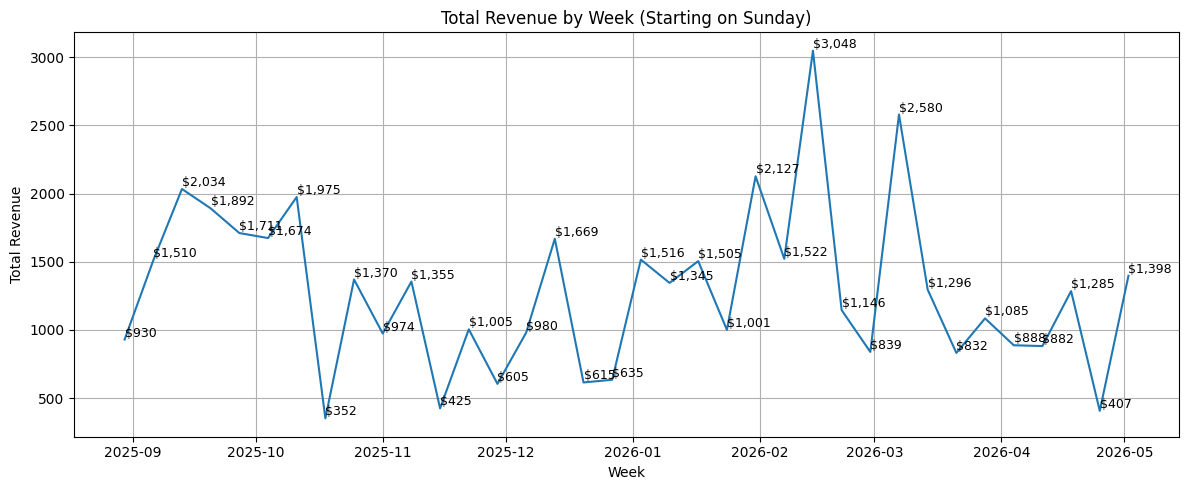

In [35]:
import pandas as pd

# Call the new function to plot weekly revenue (defaulting to 'weekly')
plot_weekly_revenue(df_raw_merged, plot_type='weekly')

NOTE TO SELF: Decicion trees on weekly sales.

FEATURES:


In [36]:
import pandas as pd
import numpy as np

def analyze_sales_by_months_since_auction(df):
    """
    Calculates the percentage of total revenue derived from sales based on the
    number of months since the item was auctioned.

    Args:
        df (pd.DataFrame): The DataFrame containing sales data with 'sale_date',
                           'Auction_Date', and 'revenue' columns.

    Returns:
        pd.DataFrame: A DataFrame showing 'months_since_auction' and 'percentage_of_total_revenue'.
    """
    df_copy = df.copy()

    # Ensure dates are datetime objects
    df_copy['sale_date'] = pd.to_datetime(df_copy['sale_date'])
    df_copy['Auction_Date'] = pd.to_datetime(df_copy['Auction_Date'])

    # Calculate the difference in months
    # Using a simple approximation: (sale_year - auction_year) * 12 + (sale_month - auction_month)
    df_copy['months_since_auction'] = (
        (df_copy['sale_date'].dt.year - df_copy['Auction_Date'].dt.year) * 12 +
        (df_copy['sale_date'].dt.month - df_copy['Auction_Date'].dt.month)
    )

    # Ensure months_since_auction is non-negative
    df_copy['months_since_auction'] = df_copy['months_since_auction'].apply(lambda x: max(0, x))

    # Calculate total revenue
    total_revenue = df_copy['revenue'].sum()

    if total_revenue == 0:
        print("Total revenue is zero, cannot calculate percentages.")
        return pd.DataFrame(columns=['months_since_auction', 'total_revenue_for_month', 'percentage_of_total_revenue'])

    # Group by months_since_auction and sum revenue
    revenue_by_month_diff = df_copy.groupby('months_since_auction')['revenue'].sum().reset_index()
    revenue_by_month_diff.rename(columns={'revenue': 'total_revenue_for_month'}, inplace=True)

    # Calculate percentage of total revenue
    revenue_by_month_diff['percentage_of_total_revenue'] = (
        revenue_by_month_diff['total_revenue_for_month'] / total_revenue
    )

    # Sort for better readability
    revenue_by_month_diff = revenue_by_month_diff.sort_values(by='months_since_auction').reset_index(drop=True)

    print("Percentage of Total Revenue by Months Since Auction:")
    display(revenue_by_month_diff.style.format({
        'total_revenue_for_month': '${:,.2f}',
        'percentage_of_total_revenue': '{:.2%}'
    }))

    return revenue_by_month_diff

# Call the function with df_raw_merged (assuming it's loaded from import_auction_data())
if 'df_raw_merged' in globals():
    sales_by_month_diff = analyze_sales_by_months_since_auction(df_raw_merged)
else:
    print("df_raw_merged not found. Please ensure import_auction_data() is run first.")


Percentage of Total Revenue by Months Since Auction:


,months_since_auction,total_revenue_for_month,percentage_of_total_revenue
0,0,"$10,969.00",23.59%
1,1,"$14,809.00",31.84%
2,2,"$7,951.25",17.10%
3,3,"$4,629.00",9.95%
4,4,"$2,723.50",5.86%
5,5,"$1,717.50",3.69%
6,6,"$2,174.00",4.67%
7,7,"$1,484.00",3.19%
8,8,$50.00,0.11%


**Projections**

In [37]:
# Estimate future revenue and profit
#estimation_end_date, estimated_future_revenue, estimated_future_cumulative_profit = estimate_future_revenue_and_profit(df_cumulative_profit, df_raw_merged)

# Calculate the total estimated profit by summing the estimated future cumulative profit for all auctions
#total_estimated_profit = sum(estimated_future_cumulative_profit.values())

#print(f"Total estimated profit one month from the latest sale date: ${total_estimated_profit:,.2f}")

# Call the function to plot total cumulative profit with projection data
#plot_total_cumulative_profit_with_projection(df_cumulative_profit, estimation_end_date, estimated_future_cumulative_profit)

In [38]:
from sklearn.linear_model import LinearRegression # Import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Redefine the function with the fix for 'to_ordinal' attribute error
def plot_overall_cumulative_profit_with_projection_and_labels(overall_daily_profit_full):
    """
    Generates an interactive Plotly line chart showing overall cumulative net profit over time,
    including linear and polynomial regression projections to Dec 31, 2026, and data labels at peaks,
    projection end, and end of actual data.

    Args:
        overall_daily_profit_full (pd.DataFrame): DataFrame containing 'sale_date' and 'daily_net_profit'.
    """
    # Ensure the 'sale_date' column is in datetime format and sorted
    overall_daily_profit_full['sale_date'] = pd.to_datetime(overall_daily_profit_full['sale_date'])
    overall_daily_profit_full = overall_daily_profit_full.sort_values(by='sale_date')

    # Calculate the cumulative net profit
    overall_daily_profit_full['cumulative_net_profit'] = overall_daily_profit_full['daily_net_profit'].cumsum()

    # Prepare data for regression models
    overall_daily_profit_full['date_ordinal'] = overall_daily_profit_full['sale_date'].apply(datetime.toordinal)
    X = overall_daily_profit_full['date_ordinal'].values.reshape(-1, 1)
    y = overall_daily_profit_full['cumulative_net_profit'].values

    # --- Prepare Projection Date Range ---
    projection_end_date = datetime(2026, 8, 19) # December 31, 2026
    full_projection_dates_range = pd.date_range(start=overall_daily_profit_full['sale_date'].min(), end=projection_end_date, freq='D')
    projection_dates_ordinal = np.array([d.toordinal() for d in full_projection_dates_range]).reshape(-1, 1)

    # --- Linear Regression for Projection ---
    linear_model = LinearRegression()
    linear_model.fit(X, y)
    predicted_profit_linear = linear_model.predict(projection_dates_ordinal)

    # --- Polynomial Regression for Projection (Degree 2) ---
    polynomial_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
    polynomial_model.fit(X, y)
    predicted_profit_polynomial = polynomial_model.predict(projection_dates_ordinal)

    # Create the interactive line chart for cumulative net profit
    fig = px.line(overall_daily_profit_full, x='sale_date', y='cumulative_net_profit',
                  title='Overall Cumulative Net Profit Over Time with Linear and Polynomial Regression Projections')

    # Add the Linear Regression projection line
    fig.add_trace(go.Scatter(
        x=full_projection_dates_range,
        y=predicted_profit_linear,
        mode='lines',
        name='Linear',
        line=dict(dash='dot', color='red')
    ))

    # Add the Polynomial Regression projection line
    fig.add_trace(go.Scatter(
        x=full_projection_dates_range,
        y=predicted_profit_polynomial,
        mode='lines',
        name='Polynomial',
        line=dict(dash='dot', color='blue')
    ))

    # --- Add data labels at peaks ---
    peaks = overall_daily_profit_full[
        (overall_daily_profit_full['cumulative_net_profit'].shift(1) < overall_daily_profit_full['cumulative_net_profit']) &
        (overall_daily_profit_full['cumulative_net_profit'].shift(-1) < overall_daily_profit_full['cumulative_net_profit'])
    ].copy()

    if peaks.empty or (len(peaks) < 2 and not overall_daily_profit_full.empty):
        last_point = overall_daily_profit_full.iloc[[-1]].copy()
        if not last_point.empty and not (peaks['sale_date'] == last_point['sale_date'].iloc[0]).any():
            peaks = pd.concat([peaks, last_point])

    peaks = peaks.sort_values(by='sale_date')

    if not peaks.empty:
        fig.add_trace(go.Scatter(
            x=peaks['sale_date'],
            y=peaks['cumulative_net_profit'],
            mode='text',
            text=peaks['cumulative_net_profit'].apply(lambda x: f'${x:,.0f}'),
            textposition='top center',
            showlegend=False,
            name='Peaks',
            textfont=dict(color='darkred', size=10)
        ))
    # --- End add data labels at peaks ---

    # --- Add data label for the estimate at the end of the Linear projection ---
    estimated_profit_eoy_linear = predicted_profit_linear[-1] # Get the last predicted value for linear
    fig.add_trace(go.Scatter(
        x=[projection_end_date],
        y=[estimated_profit_eoy_linear],
        mode='text',
        text=[f'Linear: ${estimated_profit_eoy_linear:,.0f}'],
        textposition='bottom right',
        showlegend=False,
        name='Linear Estimate',
        textfont=dict(color='red', size=10, weight='bold')
    ))
    # --- Add data label for the estimate at the end of the Polynomial projection ---
    estimated_profit_eoy_polynomial = predicted_profit_polynomial[-1] # Get the last predicted value for polynomial
    fig.add_trace(go.Scatter(
        x=[projection_end_date],
        y=[estimated_profit_eoy_polynomial],
        mode='text',
        text=[f'Poly: ${estimated_profit_eoy_polynomial:,.0f}'],
        textposition='top right',
        showlegend=False,
        name='Polynomial Estimate',
        textfont=dict(color='blue', size=10, weight='bold')
    ))
    # --- End add data label for the estimate ---

    # --- Add data label for the end of the current actual data ---
    last_actual_date = overall_daily_profit_full['sale_date'].iloc[-1]
    last_actual_profit = overall_daily_profit_full['cumulative_net_profit'].iloc[-1]
    fig.add_trace(go.Scatter(
        x=[last_actual_date],
        y=[last_actual_profit],
        mode='text',
        text=[f'Actual: ${last_actual_profit:,.0f}'],
        textposition='bottom center',
        showlegend=False,
        name='Last Actual Profit',
        textfont=dict(color='green', size=10, weight='bold')
    ))
    # --- End add data label for the end of the current actual data ---

    # Update layout for better readability and white background
    fig.update_layout(
        xaxis_title='Date',
        yaxis_title='Cumulative Net Profit',
        hovermode='x unified',
        yaxis=dict(tickformat='$,.0f'), # Format y-axis as dollars with no decimal places
        plot_bgcolor='white',  # Set the plot background color to white
        paper_bgcolor='white'
    )

    # Add a horizontal line at y=0 for the break-even point
    fig.add_shape(
        type="line",
        x0=overall_daily_profit_full['sale_date'].min(),
        y0=0,
        x1=projection_end_date, # Extend the break-even line to the projection end date
        y1=0,
        line=dict(
            color="Grey",
            width=2,
            dash="dash",
        )
    )

    fig.show()

# Ensure all necessary dataframes are prepared before plotting in e60da7f9

# 1. Prepare cumulative profit data using the globally available raw dataframes
df_cumulative_profit_for_overall_plot = prepare_cumulative_profit_data(df_raw_merged, df_raw_auction_cost)

# 2. Calculate overall daily profit
overall_daily_profit_full = calculate_overall_daily_profit(df_cumulative_profit_for_overall_plot)

print("Dataframes df_cumulative_profit and overall_daily_profit_full are now prepared.")

plot_overall_cumulative_profit_with_projection_and_labels(overall_daily_profit_full)


Dataframes df_cumulative_profit and overall_daily_profit_full are now prepared.


**Listings**

In [39]:
import pandas as pd
import plotly.express as px

# Google Sheet details for the "Listings" tab
sheet_id = "1UkYDjeRaJlu3ByJYLeKzBScu7OwY6vxd2BgU-EnT41I"
gid = "944629416" # GID for the "Listings" tab
csv_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&gid={gid}"

try:
    df_listings = pd.read_csv(csv_url)
    print("Listings data imported successfully.")
except Exception as e:
    print(f"Error importing listings data: {e}")
    df_listings = pd.DataFrame() # Create an empty DataFrame on error

if not df_listings.empty:
    print("Columns in df_listings:", df_listings.columns.tolist())
    # The previous error indicates 'listing_date' is not the correct column name.
    # Based on the previous context, 'Listing_Date' seems to be the correct column for listing date.
    date_column_name = 'Listing_Date'

    # Ensure the correct date column is in datetime format
    df_listings[date_column_name] = pd.to_datetime(df_listings[date_column_name], errors='coerce')

    # Drop rows where listing_date could not be parsed
    df_listings.dropna(subset=[date_column_name], inplace=True)

    # Aggregate the number of listings per day
    daily_listings = df_listings.groupby(date_column_name).size().reset_index(name='number_of_listings')
    daily_listings.rename(columns={date_column_name: 'listing_date'}, inplace=True)

    # Define the start date for plotting
    plot_start_date = pd.to_datetime('2026-04-30')

    # Filter data from the specified start date
    filtered_daily_listings = daily_listings[daily_listings['listing_date'] >= plot_start_date]

    if not filtered_daily_listings.empty:
        # Create the line chart
        fig = px.line(
            filtered_daily_listings,
            x='listing_date',
            y='number_of_listings',
            title='Number of Listings Per Day Starting 2026-04-30',
            labels={'listing_date': 'Date', 'number_of_listings': 'Number of Listings'}
        )

        # Customize layout for better readability
        fig.update_layout(
            xaxis_title='Date',
            yaxis_title='Number of Listings',
            hovermode='x unified',
            plot_bgcolor='white',
            paper_bgcolor='white'
        )

        fig.show()
    else:
        print(f"No listings found on or after {plot_start_date.strftime('%Y-%m-%d')}.")
else:
    print("Listings DataFrame is empty, cannot proceed with charting.")

Listings data imported successfully.
Columns in df_listings: ['Auction_Date', 'Listing_Date', 'Title', 'Storage_Location', 'Sold']


**Product Categories**

Product Category Analysis:


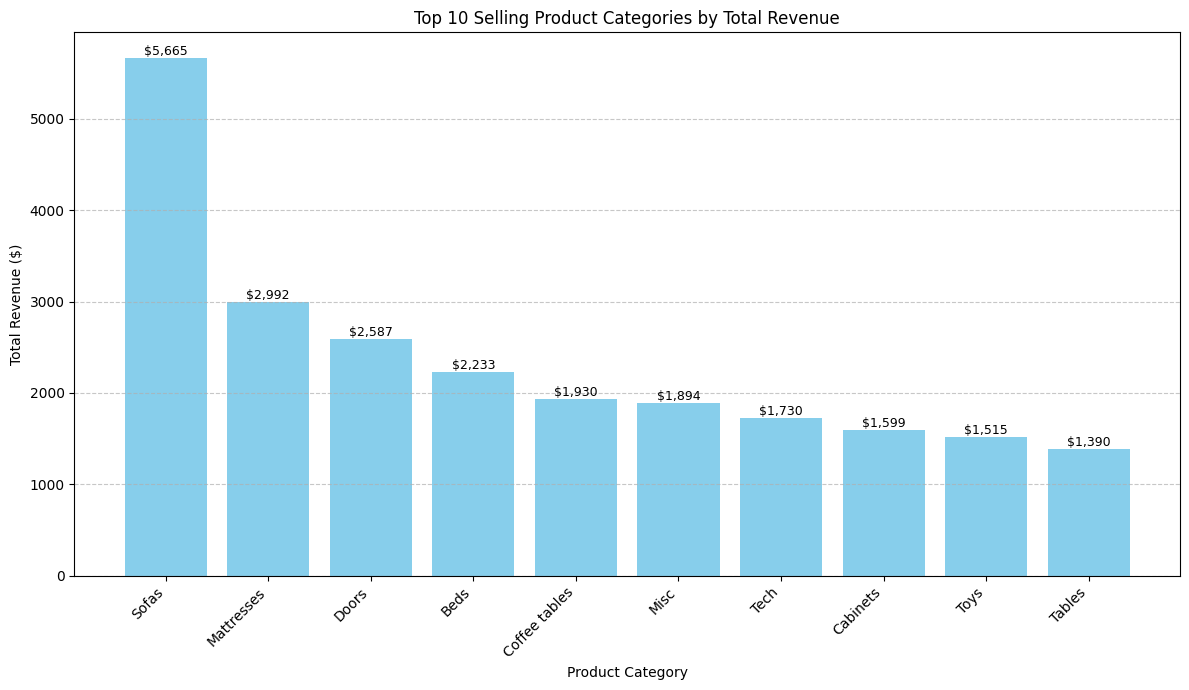

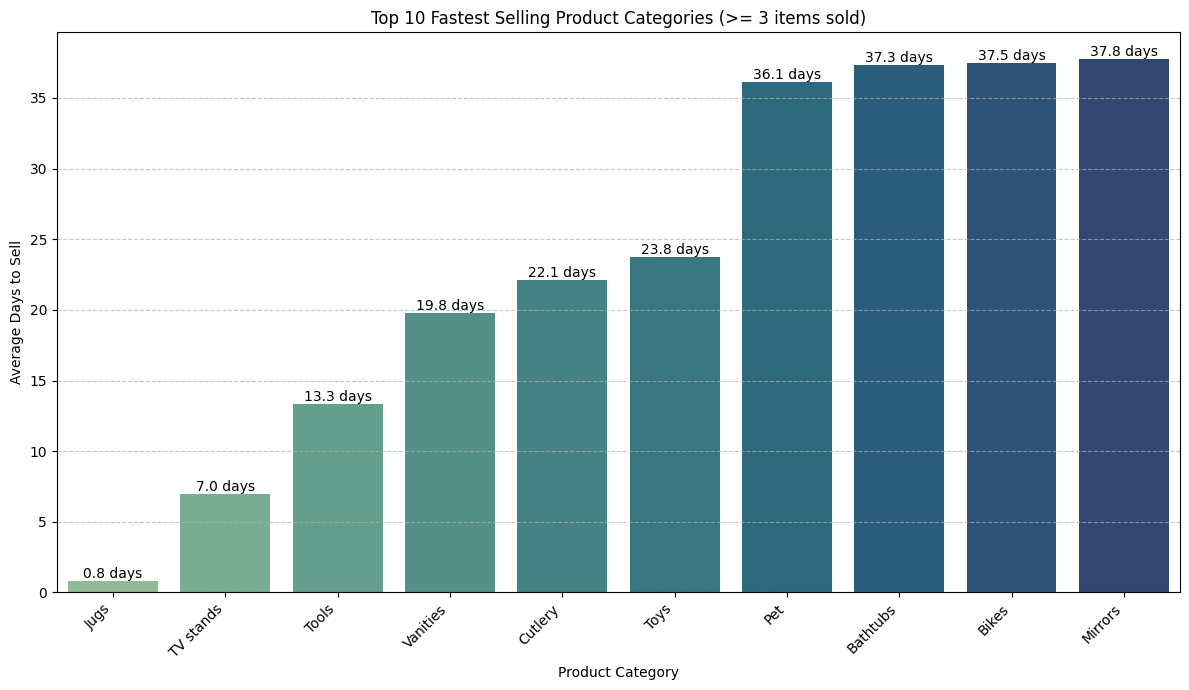

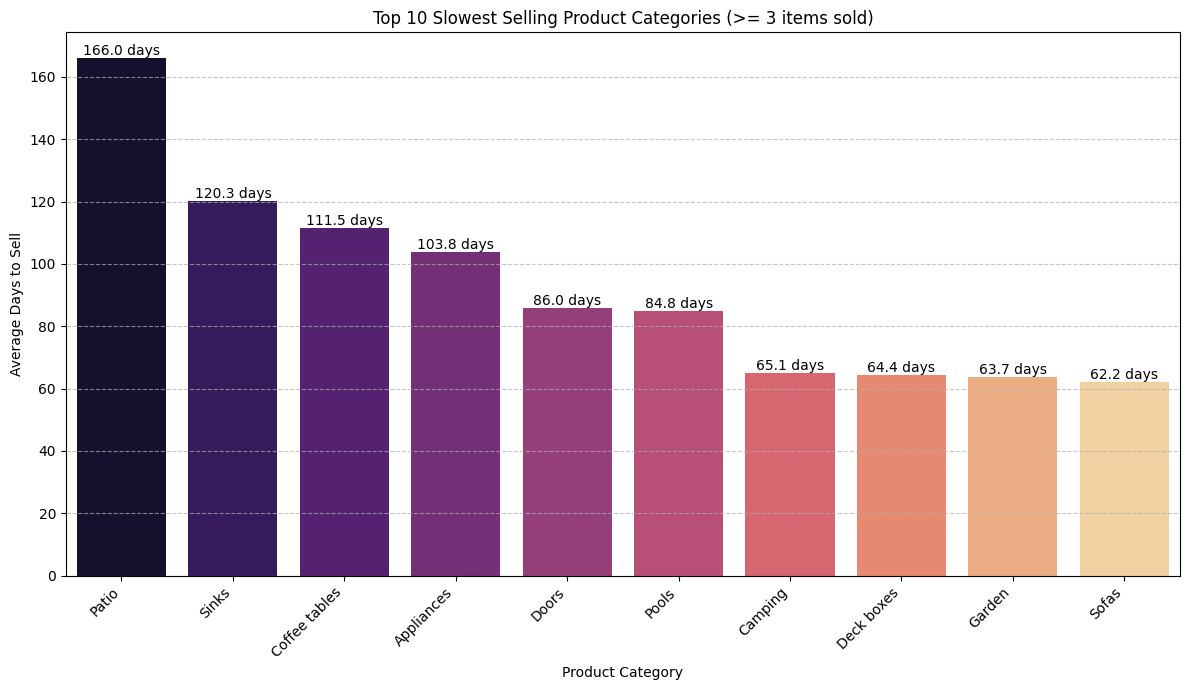

,product_category,item_count,average_selling_price,average_days_to_sell
0,Appliances,5,270.000000,103.800000
1,Bathtubs,3,380.000000,37.333333
2,Bed,1,85.000000,16.000000
3,Bedding,1,20.000000,0.000000
4,Beds,21,106.333333,48.714286


In [40]:
# Use the globally available df_raw_merged
category_summary = analyze_product_categories(df_raw_merged)
display(category_summary.head())

**Day of Week**

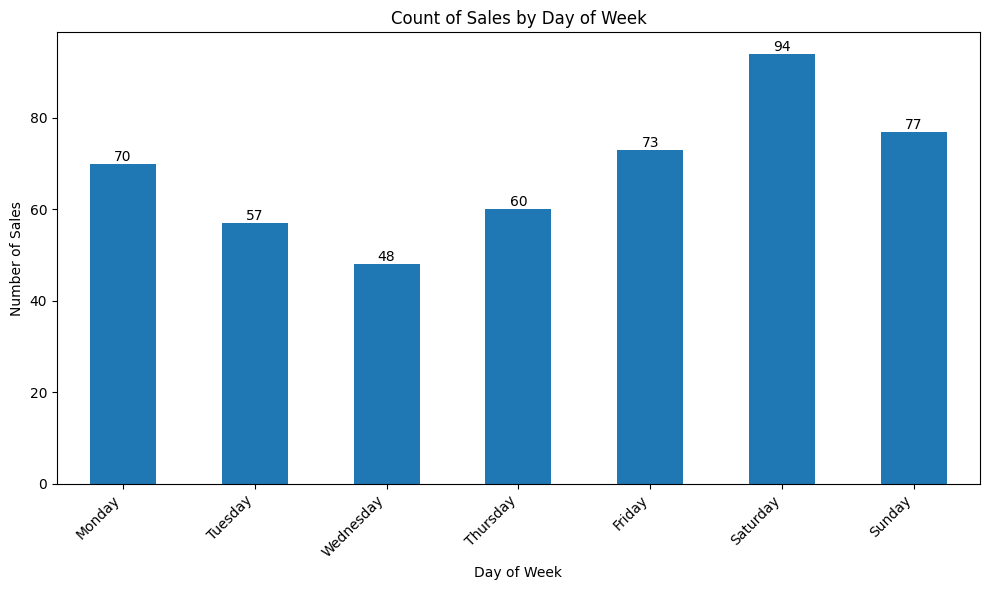

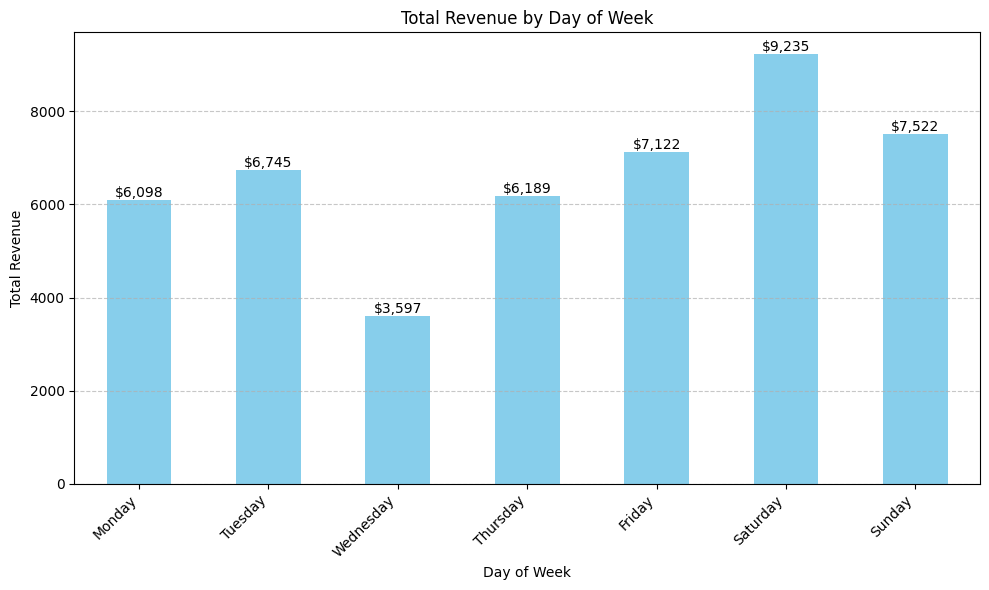

In [41]:
# Call the combined function to plot daily sales metrics using the globally available raw data
plot_daily_sales_summary(df_raw_merged)

In [42]:
import pandas as pd

# Prepare the cumulative profit data using the prepare_cumulative_profit_data function
df_cumulative_profit = prepare_cumulative_profit_data(df_raw_merged, df_raw_auction_cost)

# Calculate and print profit milestones using the new function
calculate_profit_milestones(df_cumulative_profit)


Average time to break even: 59 days
Average time to reach $1000 profit: 54 days


## Venmo

In [43]:
# Call the new function to analyze and display yearly Venmo underwriting performance
yearly_summary_venmo = analyze_yearly_venmo_underwriting(df_raw_merged, df_raw_auction_cost)

Total sales via Venmo: $29,352.25

Yearly Underwriting Performance (Venmo Revenue Only):


,year,total_revenue,total_auction_cost,profit
0,2025,"$14,247","$19,728","$-5,481"
1,2026,"$15,105","$11,081","$4,024"


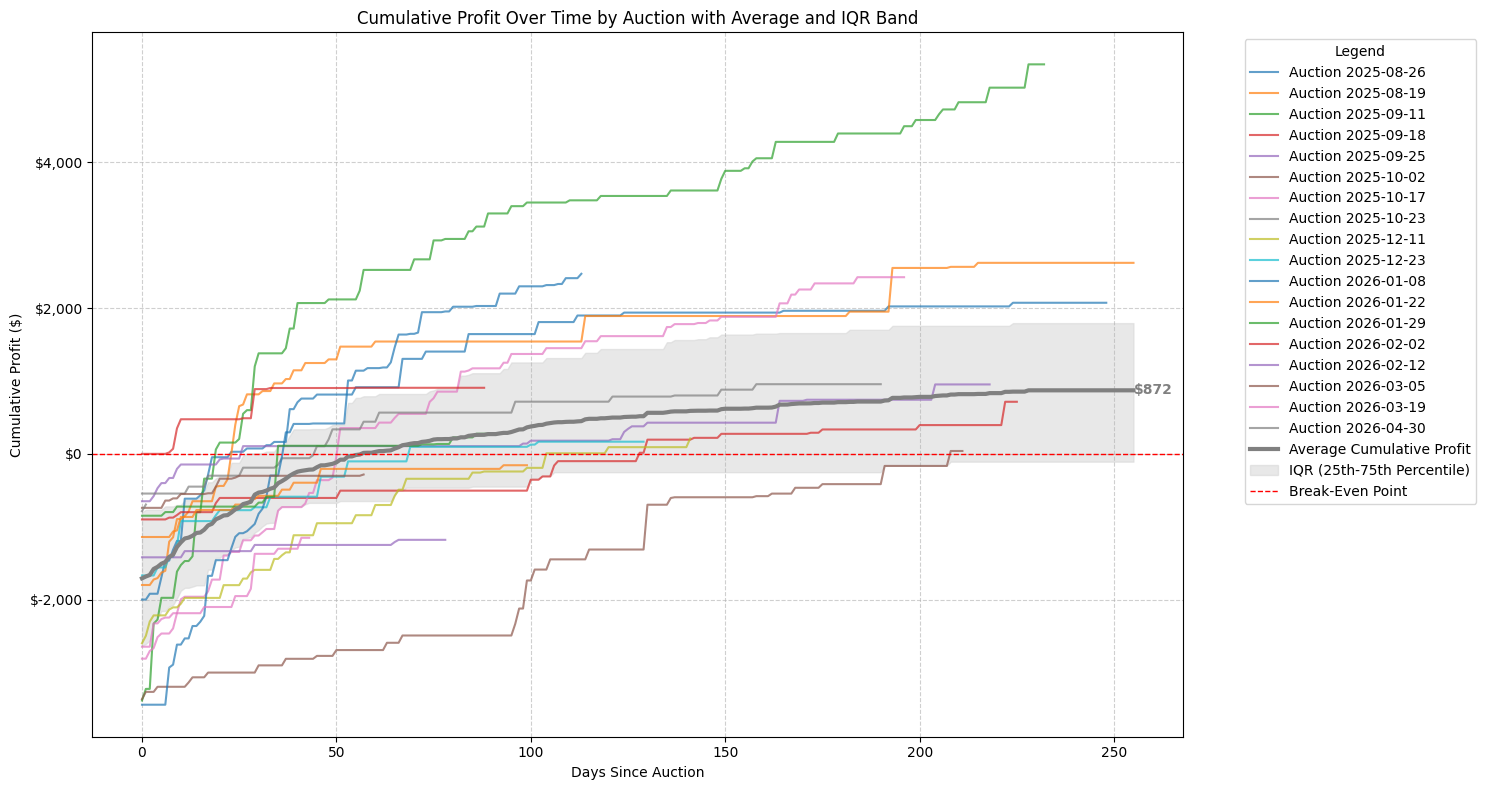

In [44]:
# Call the new function to plot cumulative profit with average and IQR band
plot_cumulative_profit_with_average_and_iqr(df_cumulative_profit)
